# An alternative approach

For one of our most methodologically in depth discussions we will dive into implementing the topic modelling approach using stochastic block modelling. This is a compare and contrast sort of class as Latent Dirichlet Allocation is a statistical, parametric approach (fitting a known statistical distribution) while Stochastic Block Modelling is a generative, non-parametric approach. Stochastic block models resurged in awareness/popularity through its applications to networks. 

![](https://media.springernature.com/full/springer-static/image/art%3A10.1038%2Fs41598-018-31202-1/MediaObjects/41598_2018_31202_Fig1_HTML.png?as=webp)

While a bit later than the initial LDA paper, Gerlach, Peixoto, and Altmann show the connection between topic modelling and community detection in their 2018 Science Advances paper -> 

M. Gerlach, T. P. Peixoto, and E. G. Altmann, A network approach to topic models, Science Advances 4, eaaq1360 (2018) or [arXiv:1708.01677] .

Specifically that in the Bayesian formulations of the LDA model is a parametricized hierarchical Stochastic Block Model. 

![](https://www.science.org/cms/10.1126/sciadv.aaq1360/asset/9bf33fa6-4645-460b-9073-e2feddd314b9/assets/graphic/aaq1360-f2.jpeg)

So what does this mean? Well the simple reality is that any parameterized model will struggle to accurately predict the structure of data if that data does not conform the model distribution. This can be seen in the following graphic of sythetic data and how it its structure is recaptured by teh two methods. 

![](https://www.science.org/cms/10.1126/sciadv.aaq1360/asset/e54b7a86-f19a-4e08-a9bd-d3974ff39de6/assets/graphic/aaq1360-f3.jpeg)

The behavior of the model also differs (arguably in a positive way) than you may be conditioned to think based on our results with the LDA implementation in Gensim

![](https://www.science.org/cms/10.1126/sciadv.aaq1360/asset/08ed5230-06d3-4dee-9251-b017530e7df7/assets/graphic/aaq1360-f5.jpeg)

# Theory into Practice and The typical sticking point

Now the next part is to install the graph-tool package. On linux this is easy, which Callisto is. But on Windows it's impossible and on Mac it can be a touchy process. 

In [2]:
!conda install graph-tool -y

Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 24.5.0
    latest version: 25.11.0

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /opt/conda

  added / updated specs:
    - graph-tool


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    _x86_64-microarch-level-4  |           3_zen4          10 KB  conda-forge
    at-spi2-atk-2.38.0         |       h0630a04_3         332 KB  conda-forge
    at-spi2-core-2.40.3        |       h0630a04_0         643 KB  conda-forge
    atk-1.0-2.38.0             |       h04ea711_2         348 KB  conda-forge
    aws-c-auth-0.9.1           |       h48c9088_3         120 KB  conda-forge
    aws-c-cal-0.9.2            |       he7b75e1_1          50 KB  conda-forge
    aws-c-common-0.12.4   

And then we would normally need to download the Git package for the rest of the modules, but I've already added the `sbmtm` and `sbmmultilayer` class files to the repository.

In [9]:
import os
import pylab as plt
%matplotlib inline 

from sbmtm import sbmtm
import graph_tool.all as gt

For ease of use, we will start with the data from the paper -- a selection of wikipedia articles.

In [6]:
path_data = '../../data/text_data/'

## texts
fname_data = 'wiki_corpus.txt'
filename = os.path.join(path_data,fname_data)

with open(filename,'r', encoding = 'utf8') as f:
    x = f.readlines()
texts = [h.split() for h in x]

## titles
fname_data = 'wiki_titles.txt'
filename = os.path.join(path_data,fname_data)

with open(filename,'r', encoding = 'utf8') as f:
    x = f.readlines()
titles = [h.split()[0] for h in x]

In [7]:
	i_doc = 0
print(titles[0])
print(texts[i_doc][:10])

Nuclear_Overhauser_effect
['the', 'nuclear', 'overhauser', 'effect', 'noe', 'is', 'the', 'transfer', 'of', 'nuclear']


## Fit the model

In [10]:
## we create an instance of the sbmtm-class
model = sbmtm()

## we have to create the word-document network from the corpus
model.make_graph(texts,documents=titles)

## fit the model
gt.seed_rng(32) ## seed for graph-tool's random number generator --> same results
model.fit()

<NestedBlockState object, with base <BlockState object with 3203 blocks (59 nonempty), degree-corrected, for graph <Graph object, undirected, with 3203 vertices and 13050 edges, 2 internal vertex properties, 1 internal edge property, at 0x7f2085062c90>, at 0x7f207d337090>, and 5 levels of sizes [(3203, 59), (59, 10), (10, 3), (3, 2), (2, 1)] at 0x7f207d33e2d0>


# Plotting the result

The output shows the (hierarchical) community structure in the word-document network as inferred by the stochastic block model:

* document-nodes are on the left
* word-nodes are on the right
* different colors correspond to the different groups

The result is a grouping of nodes into groups on multiple levels in the hierarchy:

* on the uppermost level, each node belongs to the same group (square in the middle)
* on the next-lower level, we split the network into two groups: the word-nodes and the document-nodes (blue sqaures to the left and right, respectively). This is a trivial structure due to the bipartite character of the network.
* only next lower levels constitute a non-trivial structure: We now further divide nodes into smaller groups (document-nodes into document-groups on the left and word-nodes into word-groups on the right)

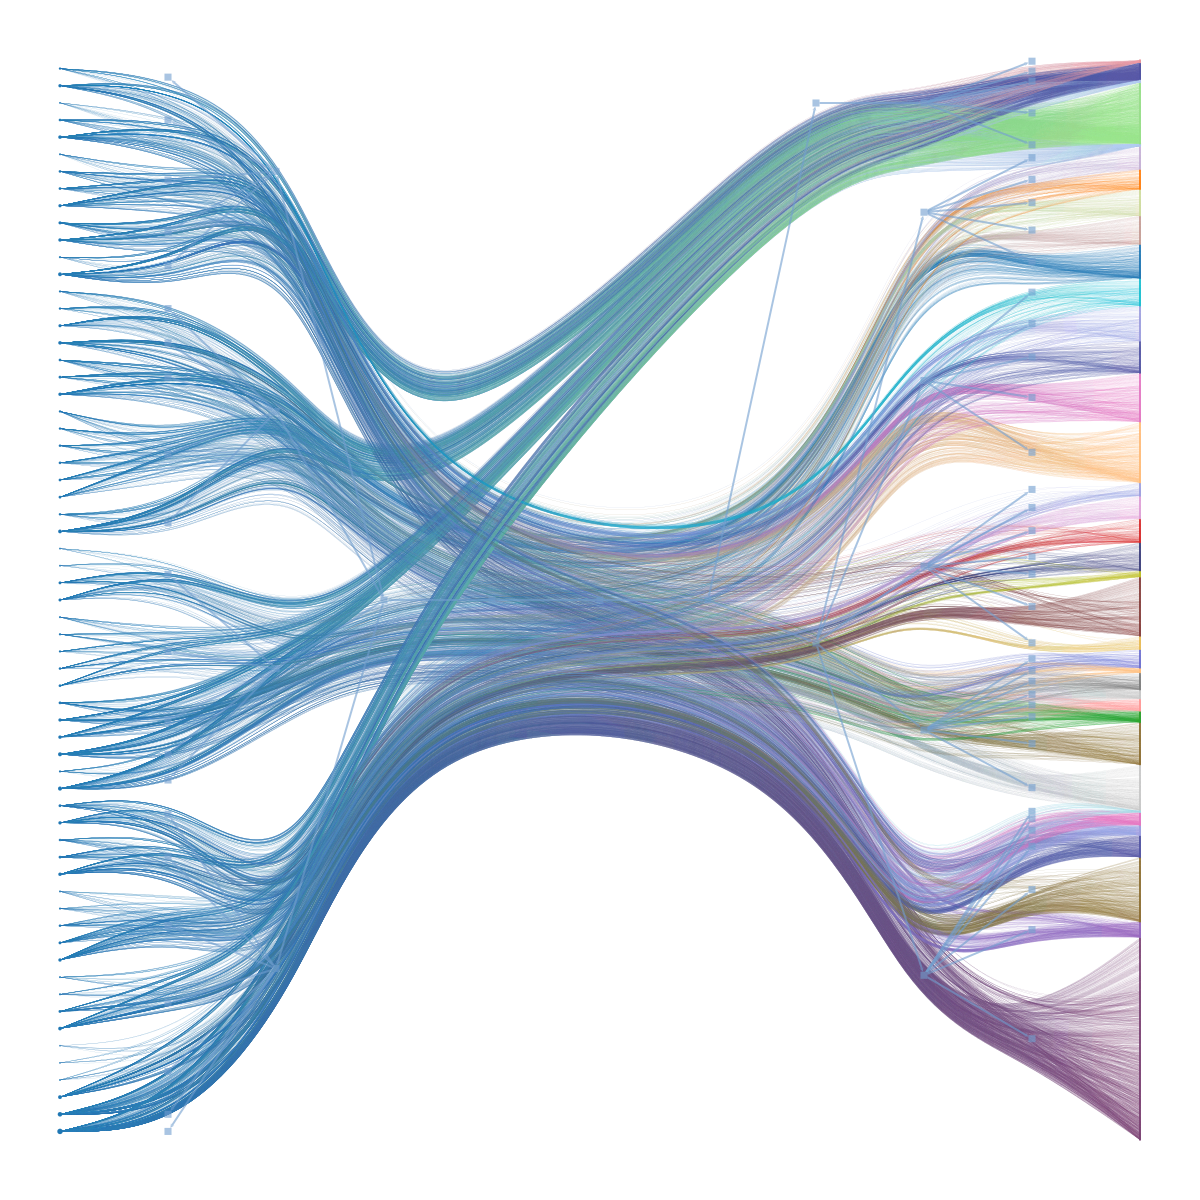

In [11]:
model.plot(nedges=10000)

# Topic recovery and more

for every word group at a fiven level we can retrieve the *n* most common words in the group -- which constitutes the topic. So at leavel 1 in the hierarchy we can see:

In [13]:
model.topics(l=1, n=20)

{0: [('the', 0.1631820499745028),
  ('of', 0.09209586945436002),
  ('and', 0.05721570627231005),
  ('a', 0.05344212136664967),
  ('to', 0.05181030086690464),
  ('in', 0.049923508414074454),
  ('is', 0.04135645079041306),
  ('for', 0.02182559918408975),
  ('as', 0.020346761856195817),
  ('that', 0.016471188169301376),
  ('are', 0.015757266700662926),
  ('by', 0.014584395716471188),
  ('be', 0.014125446200917898),
  ('on', 0.012646608873023968),
  ('with', 0.012493625701172871),
  ('an', 0.012340642529321775),
  ('this', 0.011371749107598163),
  ('can', 0.01055583885772565),
  ('which', 0.010453850076491586),
  ('or', 0.0098419173890872)],
 1: [('electron', 0.0244195356285028),
  ('electric', 0.021617293835068056),
  ('molecule', 0.020016012810248198),
  ('spin', 0.018815052041633307),
  ('frequency', 0.01521216973578863),
  ('normal', 0.01401120896717374),
  ('electrons', 0.01401120896717374),
  ('effect', 0.013610888710968775),
  ('wave', 0.012409927942353884),
  ('nuclear', 0.01160928

In [15]:
# And you see that we can move up a level and only get the two topics

model.topics(l=2, n=20)

{0: [('the', 0.1631820499745028),
  ('of', 0.09209586945436002),
  ('and', 0.05721570627231005),
  ('a', 0.05344212136664967),
  ('to', 0.05181030086690464),
  ('in', 0.049923508414074454),
  ('is', 0.04135645079041306),
  ('for', 0.02182559918408975),
  ('as', 0.020346761856195817),
  ('that', 0.016471188169301376),
  ('are', 0.015757266700662926),
  ('by', 0.014584395716471188),
  ('be', 0.014125446200917898),
  ('on', 0.012646608873023968),
  ('with', 0.012493625701172871),
  ('an', 0.012340642529321775),
  ('this', 0.011371749107598163),
  ('can', 0.01055583885772565),
  ('which', 0.010453850076491586),
  ('or', 0.0098419173890872)],
 1: [('formula', 0.0106001791579576),
  ('s', 0.00920672837662984),
  ('folding', 0.00791280979396835),
  ('was', 0.007713745396635812),
  ('protein', 0.006917487807305663),
  ('home', 0.0063202946153080525),
  ('field', 0.004976609933313427),
  ('data', 0.004329650641982681),
  ('its', 0.004031054045983876),
  ('first', 0.003981287946650741),
  ('stru

We can also check the distribution of topics that make up a document

In [16]:
## select a document (by its index)
i_doc = 0
print(model.documents[i_doc])
## get a list of tuples (topic-index, probability)
model.topicdist(i_doc,l=1)

Nuclear_Overhauser_effect


[(0, 0.4755244755244755),
 (1, 0.25524475524475526),
 (2, 0.12937062937062938),
 (3, 0.05944055944055944),
 (4, 0.055944055944055944),
 (5, 0.024475524475524476)]

In [17]:
## select a document (by its index)
i_doc = 40
print(model.documents[i_doc])
## get a list of tuples (topic-index, probability)
model.topicdist(i_doc,l=1)

Fragment_separator


[(0, 0.575),
 (1, 0.016666666666666666),
 (2, 0.125),
 (3, 0.016666666666666666),
 (4, 0.25833333333333336),
 (5, 0.008333333333333333)]

# Freebies -- document clustering as a part of the method itself

The clustering of words produces the topics and then we get the distribution of topics to documents (which is normal). But we do not typically get the sorting of documents into groups with LDA like we do with the SBM.

In [20]:
model.clusters(l=1,n=5)

{0: [('Quantum_oscillations_(experimental_technique)', 1.0),
  ('Faraday_cup_electrometer', 1.0),
  ('Rotating_wave_approximation', 1.0),
  ('Rovibrational_coupling', 1.0),
  ('Nuclear_Overhauser_effect', 1.0)],
 1: [('Sepp_Hochreiter', 1.0),
  ('Law_of_Maximum', 1.0),
  ('Dynamic_mode_decomposition', 1.0),
  ('Philosophical_interpretation_of_classical_physics', 1.0),
  ('Line_source', 1.0)],
 2: [('Point_source', 1.0),
  ("Euler's_laws_of_motion", 1.0),
  ('X-ray_crystal_truncation_rod', 1.0),
  ('X-ray_standing_waves', 1.0),
  ('Fragment_separator', 1.0)],
 3: [('De_novo_transcriptome_assembly', 1.0),
  ('BioUML', 1.0),
  ('Knotted_protein', 1.0),
  ('IEEE/ACM_Transactions_on_Computational_Biology_and_Bioinformatics', 1.0),
  ('Aureus_Sciences', 1.0)]}

It's also baked into the model to return similar articles based on their topic distribution similarity

In [21]:
## select a document (index)
i_doc = 2
print(i_doc,model.documents[i_doc])
## find all articles from the same group
## print: (doc-index, doc-title)
model.clusters_query(i_doc,l=1,)

2 Rovibrational_coupling


[(0, 'Nuclear_Overhauser_effect'),
 (6, 'Dynamic_nuclear_polarisation'),
 (7, 'Knight_shift'),
 (8, 'Polarizability'),
 (10, 'Rotating_wave_approximation'),
 (12, 'Molecular_vibration'),
 (14, 'Electrostatic_deflection_(structural_element)'),
 (18, 'Molecular_beam'),
 (20, 'Ziff-Gulari-Barshad_model'),
 (26, 'Ripple_tank'),
 (29, 'Complementary_experiments'),
 (31, 'Wave_tank'),
 (34, 'Faraday_cup_electrometer'),
 (44, 'Quantum_oscillations_(experimental_technique)')]

# Extension

Now how could we apply this to the Web of Science data that we originally used with LDA that's missing titles? 

In [2]:
import json

wos = json.loads( open('../../data/text_data/wos_topic_doc.json').read() )
wos.keys()

dict_keys(['SCIENCE', 'CELL', 'JOURNAL_OF_DIFFERENTIAL_EQUATIONS', 'ASTRONOMICAL_JOURNAL', 'GEOLOGY', 'SCHIZOPHRENIA_BULLETIN', 'AMERICAN_ECONOMIC_REVIEW'])

# Challenge Extension

Now in the `text_data` folder I also have plaintext wikipedia articles (`wiki_plaintext_articles`) that we can perform this pipeline from beginning to end with. 